# A toy example with tiles

We use an image of tiles as a data matrix with redundant (low rank) structure. By subdivising the image into sections, we create separate data matrices which we decompose with PathFinder.


In [2]:
from pathfinder import utils, decomp
# -- here while dev in progress
import importlib
importlib.reload(utils)
importlib.reload(decomp)
# ---

<module 'pathfinder.decomp' from '/opt/miniconda3/envs/py38/lib/python3.8/site-packages/pathfinder/decomp.py'>

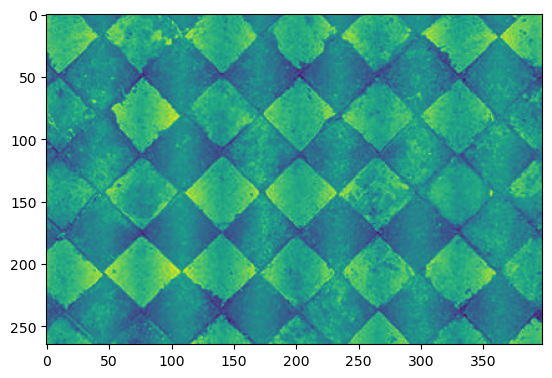

In [3]:
# Load Image and visualise it
from fsl.data.bitmap import Bitmap
import numpy as np

image_file = '../pathfinder/data/tiles.jpg'
tiles = np.array(np.flipud(np.mean(Bitmap(image_file).data,axis=-1).T),dtype=float)
# demean
tiles = tiles - np.mean(tiles, axis=0, keepdims=True)

import matplotlib.pyplot as plt
plt.imshow(tiles)
plt.show()


In [4]:
# Create dataset with missing parts
n_rows = 2
n_cols = 3

rows = np.array_split(tiles, n_rows, axis=0)
cols = [np.array_split(r, n_cols, axis=1) for r in rows]

DataComplete = {}
Data = {}
for d in range(n_rows):
    DataComplete[f'Dom{d}'] = {}
    Data[f'Dom{d}'] = {}
    for m in range(n_cols):
        DataComplete[f'Dom{d}'][f'Mod{m}'] = cols[d][m]
        Data[f'Dom{d}'][f'Mod{m}'] = cols[d][m]
        
# missing:
Data['Dom1']['Mod0'] = None
Data['Dom0']['Mod2'] = None


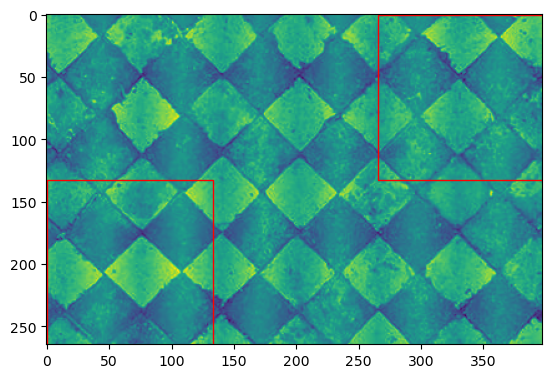

In [5]:
# Visualise 

# Plot prediction
import matplotlib

mask = np.array([[1,1,0],[0,1,1]])
mask = np.array([[1,1,1],[1,1,1]])

fig, axes = plt.subplots(1,1)

plt.imshow(tiles)

y_start = DataComplete['Dom0']['Mod0'].shape[0]
y_size  = DataComplete['Dom0']['Mod1'].shape[0]
x_start = 0
x_size  = DataComplete['Dom0']['Mod0'].shape[1]
axes.add_patch(matplotlib.patches.Rectangle((x_start,y_start), x_size, y_size, fill=False,edgecolor='r'))

y_start = 0
y_size  = DataComplete['Dom0']['Mod0'].shape[0]
x_start = DataComplete['Dom0']['Mod0'].shape[0] + DataComplete['Dom0']['Mod1'].shape[0]
x_size  = DataComplete['Dom0']['Mod2'].shape[1]
axes.add_patch(matplotlib.patches.Rectangle((x_start,y_start), x_size, y_size, fill=False,edgecolor='r'))
plt.show()


In [6]:
# Fit
from pathfinder import decomp
from sklearn.linear_model import Ridge
algo = decomp.JointOuterDecomp(n_components=10, 
                               n_iter=20, dropout=-1, 
                               method=Ridge, method_kwargs={'alpha':1e3})

algo.fit(Data)


100%|███████████████████████████████████████████| 20/20 [00:00<00:00, 94.48it/s]


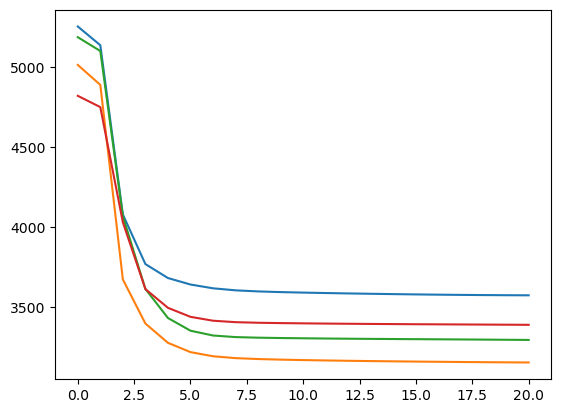

In [7]:
# look at error
import matplotlib.pyplot as plt
_ = plt.plot(algo._loss)


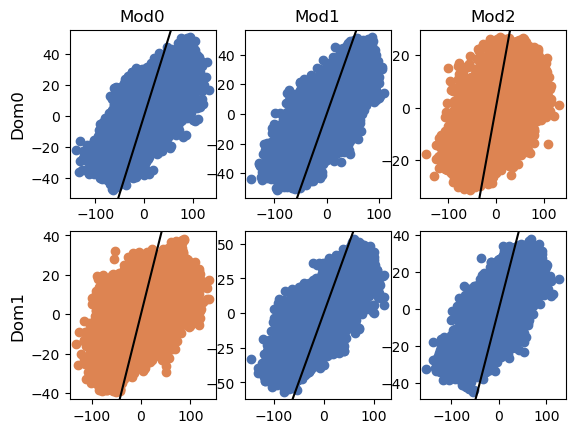

In [8]:
# # Look at fit
# from pathfinder import utils
# _ = utils.plot_data_fit(Data, algo.predict(), DataComplete)

# Plot data and fit
DataPred = algo.predict(as_dict=True)
for i, d in enumerate(DataPred):
    for j, m in enumerate(DataPred[d]):
        if DataPred[d][m] is None:
            DataPred[d][m] = algo._A[i]@algo._S[j].T
            # DataPred[d][m] = algo._Ulist[i]@algo._Vlist[j].T
            
_ = utils.plot_data_fit(Data, DataPred, DataComplete)


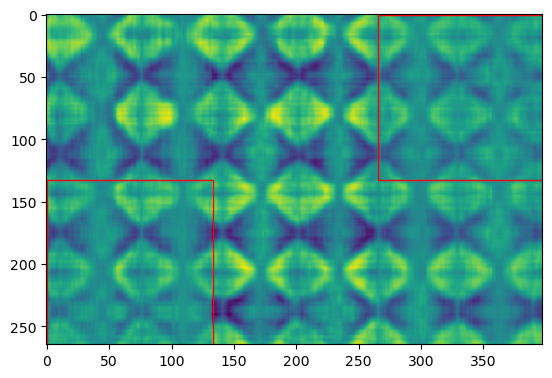

In [9]:
# Visualise
A, S = algo._A, algo._S
# Visualise 

# Plot prediction
import matplotlib

mask = np.array([[1,1,0],[0,1,1]])
mask = np.array([[1,1,1],[1,1,1]])

fig, axes = plt.subplots(1,1)

pred = np.concatenate([np.concatenate([mask[i,j]*A[i]@S[j].T for j in range(n_cols)],axis=1) for i in range(n_rows)],axis=0)
plt.imshow(pred)

y_start = DataComplete['Dom0']['Mod0'].shape[0]
y_size  = DataComplete['Dom0']['Mod1'].shape[0]
x_start = 0
x_size  = DataComplete['Dom0']['Mod0'].shape[1]
axes.add_patch(matplotlib.patches.Rectangle((x_start,y_start), x_size, y_size, fill=False,edgecolor='r'))

y_start = 0
y_size  = DataComplete['Dom0']['Mod0'].shape[0]
x_start = DataComplete['Dom0']['Mod0'].shape[0] + DataComplete['Dom0']['Mod1'].shape[0]
x_size  = DataComplete['Dom0']['Mod2'].shape[1]
axes.add_patch(matplotlib.patches.Rectangle((x_start,y_start), x_size, y_size, fill=False,edgecolor='r'))
plt.show()


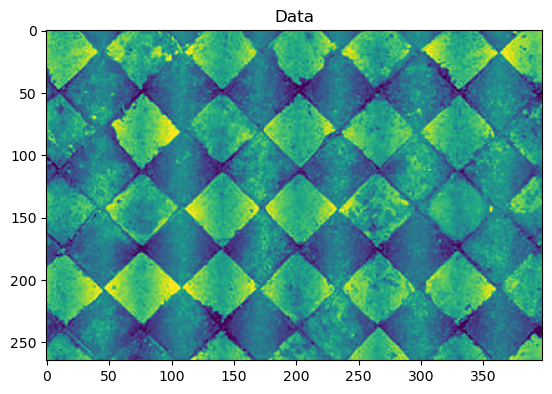

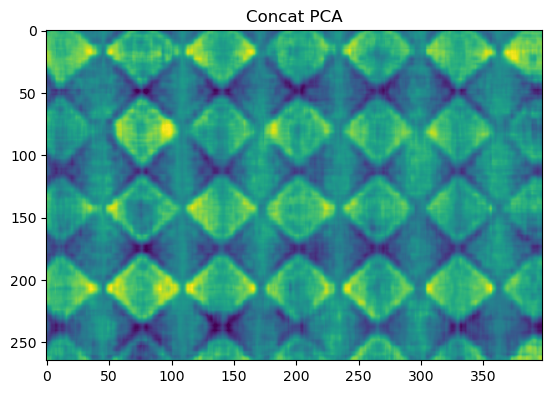

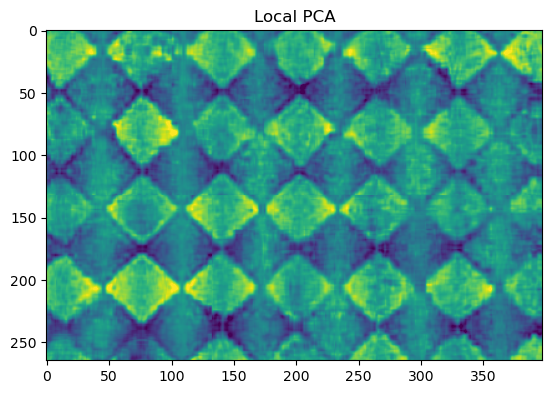

In [10]:
# Compare with PCA etc.?

from sklearn.decomposition import PCA
pca = PCA(n_components=10)
pca.fit(tiles)


plt.figure()
plt.imshow(tiles,vmin=-100,vmax=100)
plt.title('Data')
plt.show()

plt.figure()
proj = pca.inverse_transform(pca.fit_transform(tiles))
plt.imshow(proj,vmin=-100,vmax=100)
plt.title('Concat PCA')
plt.show()

proj = []
for i,d in enumerate(DataComplete):
    proj.append([])
    for j,m in enumerate(DataComplete[d]):
        proj[i].append(pca.inverse_transform(pca.fit_transform(DataComplete[d][m])))
           
pred = np.concatenate([np.concatenate([proj[i][j] for j in range(n_cols)],axis=1) for i in range(n_rows)],axis=0)
plt.imshow(pred,vmin=-100,vmax=100)
plt.title('Local PCA')
plt.show()

# TRY NON-NEGATIVE LEAST SQUARES (LIKE NMF)


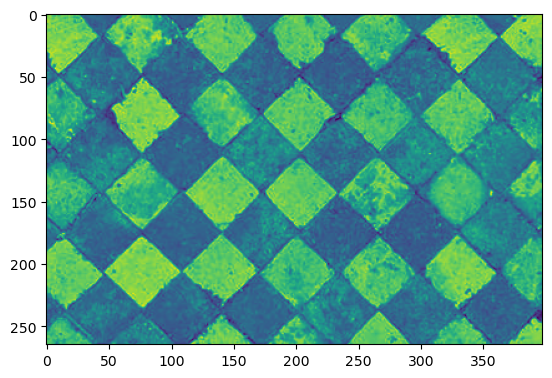

In [11]:
# Load Image and visualise it
from fsl.data.bitmap import Bitmap
import numpy as np

image_file = '../pathfinder/data/tiles.jpg'
tiles = np.array(np.flipud(np.mean(Bitmap(image_file).data,axis=-1).T),dtype=float)
# no demeaning!
# tiles = tiles - np.mean(tiles, axis=0, keepdims=True)

import matplotlib.pyplot as plt
plt.imshow(tiles)
plt.show()


In [12]:
# Create dataset with missing parts
n_rows = 2
n_cols = 3

rows = np.array_split(tiles, n_rows, axis=0)
cols = [np.array_split(r, n_cols, axis=1) for r in rows]

DataComplete = {}
Data = {}
for d in range(n_rows):
    DataComplete[f'Dom{d}'] = {}
    Data[f'Dom{d}'] = {}
    for m in range(n_cols):
        DataComplete[f'Dom{d}'][f'Mod{m}'] = cols[d][m]
        Data[f'Dom{d}'][f'Mod{m}'] = cols[d][m]
        
# missing:
Data['Dom1']['Mod0'] = None
Data['Dom0']['Mod2'] = None


In [13]:
# Fit
from pathfinder import decomp
from sklearn.linear_model import Ridge
algo = decomp.JointOuterDecomp(n_components=10, 
                               n_iter=20, dropout=-1, 
                               method=Ridge, method_kwargs={'alpha':1e2, 'positive':True})

algo.fit(Data)


100%|███████████████████████████████████████████| 20/20 [00:05<00:00,  3.35it/s]


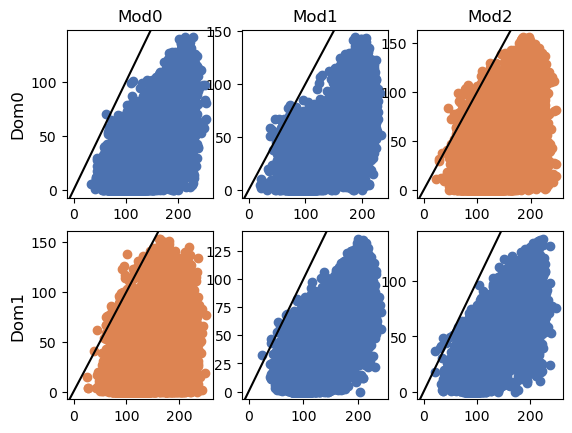

In [14]:
# # Look at fit
# from pathfinder import utils
# _ = utils.plot_data_fit(Data, algo.predict(), DataComplete)

# Plot data and fit
DataPred = algo.predict(as_dict=True)
for i, d in enumerate(DataPred):
    for j, m in enumerate(DataPred[d]):
        if DataPred[d][m] is None:
            DataPred[d][m] = algo._A[i]@algo._S[j].T
            # DataPred[d][m] = algo._Ulist[i]@algo._Vlist[j].T
            
_ = utils.plot_data_fit(Data, DataPred, DataComplete)


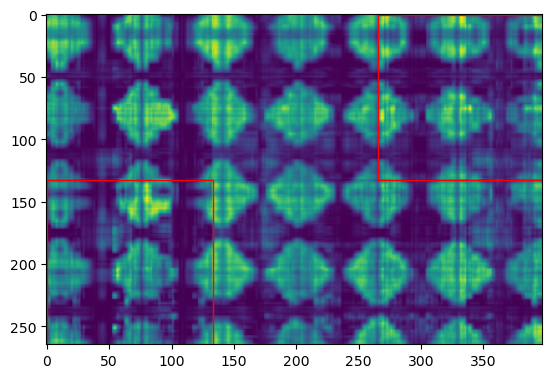

In [15]:
# Visualise
A, S = algo._A, algo._S
# Visualise 

# Plot prediction
import matplotlib

mask = np.array([[1,1,0],[0,1,1]])
mask = np.array([[1,1,1],[1,1,1]])

fig, axes = plt.subplots(1,1)

pred = np.concatenate([np.concatenate([mask[i,j]*A[i]@S[j].T for j in range(n_cols)],axis=1) for i in range(n_rows)],axis=0)
plt.imshow(pred)

y_start = DataComplete['Dom0']['Mod0'].shape[0]
y_size  = DataComplete['Dom0']['Mod1'].shape[0]
x_start = 0
x_size  = DataComplete['Dom0']['Mod0'].shape[1]
axes.add_patch(matplotlib.patches.Rectangle((x_start,y_start), x_size, y_size, fill=False,edgecolor='r'))

y_start = 0
y_size  = DataComplete['Dom0']['Mod0'].shape[0]
x_start = DataComplete['Dom0']['Mod0'].shape[0] + DataComplete['Dom0']['Mod1'].shape[0]
x_size  = DataComplete['Dom0']['Mod2'].shape[1]
axes.add_patch(matplotlib.patches.Rectangle((x_start,y_start), x_size, y_size, fill=False,edgecolor='r'))
plt.show()
